### Decision Trees: The Architecture of Rule-Based Learning

#### 1. Basic Intuition (The Ground Reality)
Machine Learning me jab hum SVM ya Logistic Regression use karte hain, toh model ek complex mathematical equation (line ya curve) banata hai jisko aam insaan ke liye padhna aur samajhna namumkin hota hai (Black-Box models). 

Lekin **Decision Tree** ekdam alag hai. Yeh bilkul waisa hi hai jaise hum insaan apni real life me decision lete hain. 
Maan lijiye aapko kisi player ko apne BGMI Esports roster me select karna hai. Aap apne dimaag me rules banayenge:
1. "Kya iska F/D ratio 4.0 se zyada hai?" -> (No -> Reject).
2. (Yes ->) "Kya iska device ping 40ms se kam rehta hai?" -> (No -> Reject).
3. (Yes ->) "Kya iske paas T1 tournaments ka experience hai?" -> (Yes -> Select).

Is "Yes/No" branching logic ko jab hum math aur data ke through automate kar dete hain, toh use Decision Tree kehte hain. Yeh ek **Non-parametric** model hai, matlab yeh pehle se assume nahi karta ki data linear hoga ya curved. Yeh bas data ko todta (split karta) chala jata hai.

---

#### 2. Core Concepts & Architecture (Evolution of Algorithms)
Decision Trees ek din me nahi bane. Pichle 40 saalon me inke algorithms lagatar evolve hue hain. Aaiye inki timeline aur architecture samajhte hain:

**A. ID3 (Iterative Dichotomiser 3)**
* **The Grandfather:** Ise 1986 me Ross Quinlan ne banaya tha. 
* **Architecture:** Yeh **Multiway Tree** banata hai. Agar aapke feature "Color" me 3 values hain (Red, Green, Blue), toh yeh node se 3 branches nikalega.
* **Limitation:** Yeh sirf Categorical data (words/labels) par chalta hai. Continuous numbers (jaise salary ya height) ko handle nahi kar pata.

**B. C4.5 (The Upgrade)**
* **The Successor:** Yeh ID3 ka advanced version tha. 
* **Superpowers:** 1. Yeh continuous numbers ko handle kar sakta hai (e.g., automatically rule banayega: `Age <= 25.5`). 
  2. Yeh missing values ko handle kar leta hai.
  3. **Rule Set Conversion:** Tree banne ke baad yeh complex branches ko simple "If-Then" English rules me convert kar deta hai, jo software engineers ko backend me if-else code likhne me madad karta hai.

**C. C5.0 (The Enterprise Version)**
* **The Commercial Engine:** Yeh C4.5 ka paid, proprietary version hai. Yeh memory bohot kam leta hai aur iski processing speed C4.5 se multi-folds fast hai. Isme advanced techniques (jaise boosting) ka early integration tha.

**D. CART (Classification and Regression Trees) - The Modern Standard**
* **The Ultimate Architecture:** Aaj kal Python (Scikit-Learn) me sirf aur sirf CART algorithm hi use hota hai.
* **Architecture:** Yeh sirf **Binary Splits** karta hai (Har node se sirf 2 branches niklengi - Yes/No). Chahe categories 10 hon, yeh unko "A vs [B,C,D...]" me tod dega.
* **Versatility:** C4.5 sirf classification karta tha, par CART target variable ko predict karne ke liye dono kaam kar sakta hai:
  * Categorical target = Classification.
  * Numerical target = Regression (average nikal kar).

---

#### 3. Advanced Mathematics (Behind the Scenes)
Tree ke saamne sabse bada sawal hota hai: *"Main sabse pehle kaunsa question puchu (Root node kaisa banau) jisse data sabse best tareeqe se alag ho jaye?"*
Ise solve karne ke liye algorithm math ka use karta hai jise **Impurity (Kachra/Mix)** kehte hain. Goal hai ki split ke baad impurity sabse kam ho.

**A. Entropy & Information Gain (Used in ID3 / C4.5)**
Entropy physics se aaya concept hai jo "Randomness" ya "Chaos" ko measure karta hai.
$$Entropy = H(S) = - \sum_{i=1}^{c} p_i \log_2(p_i)$$
* Jahan $p_i$ kisi class ki probability hai.
* Agar ek node me 50 Cats aur 50 Dogs hain (50-50 mix), toh Entropy = 1.0 (Maximum Chaos).
* Agar node me sirf 100 Cats hain, toh Entropy = 0.0 (Pure Node).
* Algorithm wo question (feature) chunta hai jisko apply karne ke baad Entropy sabse zyada gire (Drop in Entropy = Information Gain).

**B. Gini Impurity (Used in CART / Scikit-Learn)**
Scikit-Learn default me Gini use karta hai kyunki isme Logarithmic calculation nahi karni padti, isliye yeh CPU par mathematically **bohot fast** compute hota hai.
$$Gini = 1 - \sum_{i=1}^{c} (p_i)^2$$
* Gini ki value 0.0 (Pure) se 0.5 (Maximum Mix) tak jati hai.
* CART har possible threshold point check karta hai aur wo point chunta hai jahan Gini score sabse kam (minimum) ho.

---

#### 4. Real-World Industry Use-Case
**Banking Compliance & Loan Approvals:**
Maan lijiye aap HDFC Bank ke Data Scientist hain. Agar aap Loan default predict karne ke liye SVM ya Neural Network use karenge, toh model highly accurate hoga, par jab kisi customer ka loan reject hoga aur wo Reserve Bank of India (RBI) me complaint karega, toh aap bank ko justify nahi kar payenge ki "Neural Network ke weights ki wajah se loan reject hua". Yeh legal issue ban jayega.

Wahan strictly **Decision Trees (CART/C4.5)** use hote hain. Kyunki Decision Tree ek explainable model (White-Box) hai. Bank customer ko exactly bata sakta hai: *"Aapka loan reject hua kyunki: CIBIL Score < 700 AND Credit Card Utilization > 80% AND Defaults in last 6 months > 1"*. Interpretable hone ki wajah se yeh highly regulated industries (Finance, Healthcare) ka core algorithm hai.

---

#### 5. Modern Implementation (Production Grade Code)
Decision Tree ke sath sabse badi bimari hai **Overfitting**. Agar aap isko control nahi karenge, toh yeh tree tab tak data ko todta rahega jab tak har ek single data point ke liye ek alag branch na ban jaye (training accuracy 100%, test accuracy 50%). Isliye production me hum `max_depth` aur `min_samples_split` jaise hyperparameters zaroor set karte hain (ise Pre-Pruning kehte hain).


In [1]:

import numpy as np
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.datasets import load_breast_cancer

# Load real dataset
data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.2)

# Production Setup: Never run a naked Decision Tree
# We strictly define constraints (Pruning parameters)
param_grid = {
    'criterion': ['gini', 'entropy'],           # Test both CART and ID3 style logic
    'max_depth': [3, 4, 5, 6, None],            # Restrict depth to stop over-memorization
    'min_samples_split': [2, 10, 20],           # Minimum points required to split a node
    'min_samples_leaf': [1, 5, 10]              # Minimum points required to form an end-leaf
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42), 
    param_grid, 
    cv=5, 
    scoring='accuracy',
    n_jobs=-1
)

# Train the model
# grid_search.fit(X_train, y_train)
# best_tree = grid_search.best_estimator_

# The BEST feature of Decision Trees: You can print the rules!
# tree_rules = export_text(best_tree, feature_names=list(data.feature_names))
# print("Production Rules Engine logic:\n", tree_rules)

### Scikit-Learn Implementation of Trees: The CART Engine

#### 1. Basic Intuition (The Ground Reality)
Jab hum theory me Decision Trees padhte hain, toh lagta hai ki hum model ko direct words (jaise "Red", "Tall", "Yes") de sakte hain aur wo rules bana lega. Par jab hum real Python environment me aate hain, toh reality alag hoti hai.
Scikit-Learn ka engine ek highly optimized math-based engine hai jo sirf aur sirf numbers samajhta hai. Ise specifically **Optimized CART (Classification and Regression Trees)** algorithm par banaya gaya hai. Yeh algorithm itna smart hai ki yeh classification (categories batana) aur regression (exact numbers/price batana) dono ek hi tarike se handle kar leta hai, sirf math ka formula badal kar.

---

#### 2. Core Concepts & Architecture (Step-by-Step Breakdown)

**A. The "Categorical Variable" Reality Check**
Decision Tree algorithms (jaise C4.5) theoretically categorical data (words/strings) ko direct split kar sakte hain. Lekin **Scikit-Learn ka CART implementation categorical variables ko natively support nahi karta.**
* **The Reason:** Sklearn trees ko mathematically fast rakhne ke liye arrays aur matrices par optimize kiya gaya hai.
* **The Modern Solution:** Agar aapke data me categories hain (jaise City="Delhi", "Mumbai"), toh aapko unhe tree me daalne se pehle `OneHotEncoder` ya `OrdinalEncoder` se numbers me convert karna hi padega, warna sklearn error fek dega.

**B. The Dual Engines (`Classifier` vs `Regressor`)**
Sklearn me tree ke do alag-alag classes hain, par inka andar ka engine bilkul same hai:
1. `sklearn.tree.DecisionTreeClassifier`: Output ek category (0, 1, 2) hogi.
2. `sklearn.tree.DecisionTreeRegressor`: Output ek continuous number (e.g., Price = 450.50) hogi.

**C. The 4 Master Control Parameters (Hyperparameters)**
Sklearn me tree ko overfit (data ratne) se rokne ke liye humein 4 steering wheels milte hain:
1. **`max_depth` (The Brakes):** Tree kitni branches (levels) tak neeche ja sakta hai. Agar isko `None` chhod diya, toh tree tab tak badhega jab tak har patte (leaf) me sirf 1 data point na bache (Extreme Overfitting).
2. **`min_samples_split`:** Ek node ko aage tootne (split hone) ke liye kam se kam kitne data points chahiye. (Default: 2. Agar 10 set kiya, toh 9 points bache hone par tree aage nahi tootega).
3. **`min_samples_leaf`:** Tree banne ke baad, sabse aakhiri node (leaf) me kam se kam kitne points hone hi chahiye. Yeh outliers par alag rules banne se rokta hai.
4. **`splitter`:** Yeh batata hai ki split dhoondhne ki strategy kya hogi.
   * `'best'` (Default): Algorithm saare columns aur saare possible values ko check karke sabse perfect split dhoondhega (Slow but accurate).
   * `'random'`: Algorithm random columns check karega aur ek decent split chunte hi aage badh jayega. Yeh massive datasets par model ko bohot fast banata hai aur overfitting kam karta hai.

---

#### 3. Advanced Mathematics (Behind the Scenes)

Dono estimators (`Classifier` aur `Regressor`) me sab kuch same hai, siwaye ek cheez ke: **`criterion`** (Galti naapne ka math). Tree decide kaise karta hai ki kahan se split karna hai?

**For Classification (Default: 'gini'):**
Tree impurities (mix data) ko kam karne ki koshish karta hai.
$$Gini = 1 - \sum_{i=1}^{c} (p_i)^2$$
(Yaani ek node me classes kitni purely alag ho gayi hain).

**For Regression (Default: 'squared_error'):**
Regression me classes nahi hoti, numbers hote hain. Toh tree har split par dono taraf ke data ka average (mean) nikalta hai aur dekhta hai ki points apne mean se kitna door hain (Variance/Error).
$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y})^2$$
(Tree wo split chunta hai jahan dono aage wali branches me Variance / MSE sabse kam ho).

---

#### 4. Real-World Industry Use-Case
**Healthcare Diagnostic Rules (White-Box AI):**
Hospitals me jab AI models (jaise Cancer Risk Prediction) deploy hote hain, toh doctors Black-Box models (Neural Networks) par trust nahi karte. Unhe logic dekhna hota hai.
Wahan hum Scikit-Learn ka `DecisionTreeClassifier` use karte hain. Pura pipeline banaya jata hai jahan pehle categories encode hoti hain, phir strictly pruned (jaise `max_depth=4`, `min_samples_leaf=20`) tree banaya jata hai. Uske baad Sklearn ke `export_text` function ka use karke us math model ko human-readable English text me print kiya jata hai taaki doctor us logic (e.g., "If Age > 55 and Blood Pressure > 140 -> High Risk") ko verify karke approve kar sake.

---

#### 5. Modern Implementation (Production Grade Code)
Aaj kal industry me hum directly dataset ko tree me nahi daalte. Kyunki sklearn categorical variables support nahi karta, hum ek **`ColumnTransformer`** banate hain jo dynamically strings ko numbers me badal kar automatically tree ko feed karta hai.



In [2]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# Dummy Data: Combination of Numeric and Categorical (which Sklearn Trees natively hate)
df = pd.DataFrame({
    'Age': [25, 45, 35, 50, 23, 30],
    'City': ['Delhi', 'Mumbai', 'Delhi', 'Pune', 'Mumbai', 'Pune'], # Categorical
    'Outcome': [0, 1, 0, 1, 0, 0]
})

X = df[['Age', 'City']]
y = df['Outcome']

# 1. Modern Solution: Preprocessing Pipeline for Categorical Data
# Ye step strictly necessary hai CART implementation ke liye
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['City'])
    ],
    remainder='passthrough' # Age (numeric) ko direct aage bhejo
)

# 2. Building the full Engine Pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('tree', DecisionTreeClassifier(random_state=42))
])

# 3. Setting up Master Control Parameters (Preventing Overfitting)
param_grid = {
    'tree__criterion': ['gini', 'entropy'],
    'tree__max_depth': [3, 5, 7, None],
    'tree__min_samples_split': [2, 5, 10],
    'tree__min_samples_leaf': [1, 2, 5],
    'tree__splitter': ['best', 'random'] # 'random' acts as a great regularizer
}

# 4. Searching for the perfect Tree setup
grid_search = GridSearchCV(
    pipeline, 
    param_grid, 
    cv=3, 
    scoring='accuracy'
)

# Training
# grid_search.fit(X, y)
# print("Best Engine Setup:", grid_search.best_params_)

### The Math Engine of Trees: Decoding the `criterion` Parameter

#### 1. Basic Intuition (The Ground Reality)
Bhai, jab ek Decision Tree data ko todta (split karta) hai, toh use kaise pata chalta hai ki yeh split "Achha" hai ya "Bura"? 
Maan lo aap ek class ke bachho ko do groups me baat rahe ho. Agar ek group me sirf "Boys" aur dusre me sirf "Girls" hain, toh yeh ek **Perfect/Pure Split** hai. Par agar dono groups me 50-50 mix hai, toh yeh **Kachra (Impure) Split** hai. 

Tree ko is "Kachre" (Impurity) ya "Galti" (Error) ko naapne ke liye ek mathematical measuring tape chahiye hota hai. Is measuring tape ko hi Scikit-Learn me **`criterion`** kehte hain. 

* **Classification ke liye:** Yeh naapta hai ki categories kitni "Pure" (alag) ho gayi hain.
* **Regression ke liye:** Yeh naapta hai ki hamari prediction actual numbers se kitni door (Error) hai.

---

#### 2. Core Concepts & Architecture (Step-by-Step Breakdown)

**A. Classification Criteria (The Purity Checkers)**
* **`gini` (Default):** Yeh Gini Impurity calculate karta hai. Iska simple logic hai: "Agar main is group se ek random data point uthau, toh uske galat classify hone ke kitne chances hain?" Yeh computationally bohot **fast** hota hai kyunki isme complex math nahi lagta.
* **`entropy`:** Yeh Information Theory se aaya hai. Yeh data ki "Randomness" ya "Chaos" ko naapta hai. Yeh thoda **slow** hota hai kyunki isme Logarithmic (`log2`) calculations karni padti hain. Result me Gini aur Entropy me sirf 1-2% ka farq aata hai, par Entropy kabhi-kabhi thode zyada balanced (symmetrical) trees banata hai.

**B. Regression Criteria (The Error Checkers)**
* **`squared_error` (Default - formerly `mse`):** Yeh Mean Squared Error hai. Yeh badi galtiyon (outliers) ko bohot bhari saza deta hai (kyunki galti ka square ho jata hai). Agar data me extreme outliers nahi hain, toh yeh best hai.
* **`absolute_error` (formerly `mae`):** Yeh Mean Absolute Error hai. **Engineer's Secret:** Agar aapke data me bohot gande outliers hain (jaise sabki salary 5 Lakh hai par ek ki 50 Crore hai), toh MSE pure tree ko kharab kar dega. Wahan `absolute_error` use hota hai kyunki yeh outliers ko ignore kar deta hai. Par dhyan rahe, yeh chalne me MSE se bohot **slow** hota hai.
* **`friedman_mse`:** Yeh MSE ka hi ek advanced roop hai jise *Gradient Boosting Trees* (jaise XGBoost) ke liye optimize kiya gaya hai. Normal single tree me iska zyada fayda nahi hota.
* **`poisson`:** Yeh ek special mathematical distribution (Poisson) use karta hai. Isko tab use karte hain jab aapka target variable "Count" ya "Frequency" ho (jaise din me kitne customers aayenge).

---

#### 3. Advanced Mathematics (Behind the Scenes)

**Gini vs Entropy (Classification):**
Maan lijiye ek node me $p$ probability hai Class 1 ki.
* **Gini Formula:** $Gini = 1 - \sum (p_i)^2$ 
  * Agar pure hai (100% Class 1): $1 - (1^2 + 0^2) = 0$
  * Agar 50-50 mix hai: $1 - (0.5^2 + 0.5^2) = 0.5$ (Maximum Gini Impurity)
* **Entropy Formula:** $Entropy = -\sum p_i \log_2(p_i)$
  * Agar pure hai: $0$
  * Agar 50-50 mix hai: $- (0.5 \log_2(0.5) + 0.5 \log_2(0.5)) = 1.0$ (Maximum Entropy)

**MSE vs MAE (Regression):**
* **Squared Error (MSE):** $MSE = \frac{1}{n}\sum(y_i - \hat{y})^2$ (Parabola curve, bad mistakes mathematically explode).
* **Absolute Error (MAE):** $MAE = \frac{1}{n}\sum|y_i - \hat{y}|$ (V-shape curve, treats all mistakes linearly).

---

#### 4. Real-World Industry Use-Case
**1. Absolute Error in Ride-Sharing Pricing (Uber/Ola):**
Jab Uber fare (price) predict karne ka tree model banata hai, toh kabhi-kabhi GPS glitch ki wajah se historical data me ek ride ka fare ₹1,00,000 dikh sakta hai (Outlier). Agar Uber `squared_error` use karega, toh tree us ek galti ko sudharne ke chakkar me baaki normal rides ka fare badha dega. Isliye wahan pricing predictions me **`criterion='absolute_error'`** lagaya jata hai taaki outliers ka asar median (beech ke) price par na pade.

**2. Poisson in Inventory Management (Zomato/Blinkit):**
Blinkit ko predict karna hai ki agle 1 ghante me "Kitne doodh ke packets" order honge. Counts (0, 1, 2, 3...) negative nahi ho sakte aur unki ek specific wave (Poisson distribution) hoti hai. Yahan standard MSE fail ho jata hai, isliye production me **`criterion='poisson'`** use kiya jata hai.

---

#### 5. Modern Implementation (Production Grade Code)
Production me jab hum hyperparameter tuning karte hain, toh hum dono classification criteria (`gini` aur `entropy`) ya regression criteria ko GridSearch me daal dete hain, kyunki pehle se guess karna mushkil hota hai ki data ke liye math ka kaunsa rule best chalega.



In [3]:

import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.datasets import make_regression

# Generating some dummy regression data with outliers
X, y = make_regression(n_samples=1000, n_features=10, noise=0.1, random_state=42)

# Introducing massive outliers intentionally to prove a point
y[::10] += 500  # Har 10th row me bhari outlier daal diya

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Setting up a pipeline for Regression
pipeline = Pipeline([
    ('regressor', DecisionTreeRegressor(random_state=42))
])

# Testing different mathematical measuring tapes (criteria)
param_grid = {
    # Testing MSE vs MAE vs Poisson vs Friedman
    'regressor__criterion': ['squared_error', 'absolute_error', 'friedman_mse', 'poisson'],
    'regressor__max_depth': [5, 10, None],
    'regressor__min_samples_split': [2, 10]
}

# n_jobs=-1 is crucial here because 'absolute_error' takes significantly more CPU time
grid_search = GridSearchCV(
    pipeline, 
    param_grid, 
    cv=5, 
    scoring='neg_mean_absolute_error', # Evaluation metric
    n_jobs=-1
)

# grid_search.fit(X_train, y_train)
# print("Best Criterion for data with outliers:", grid_search.best_params_['regressor__criterion'])
# Output will likely favor 'absolute_error' because of the manual outliers we added.

### Tree Visualization (`plot_tree`): Bridging the Gap Between Math and Humans

#### 1. Basic Intuition (The Ground Reality)
Machine Learning me ek bohot badi problem hai: **"The Black Box Problem"**. Agar aap ek Deep Learning model banate hain aur wo kehta hai "Yeh patient cancer positive hai", toh doctor poochega "Kyun?". Neural network iska jawab nahi de sakta. 

Par Decision Trees **"White-Box"** models hote hain. Inka sabse bada superpower yeh hai ki training ke baad hum inka dimaag (logic) khol kar screen par draw kar sakte hain. Jab hum tree ko visualize karte hain, toh hum basically algorithm ki "Sochne ki Process" ko ek flowchart me convert kar rahe hote hain, jise koi bhi non-technical insaan (jaise CEO ya Doctor) aasaani se samajh sake.

---

#### 2. Core Concepts & Architecture (Step-by-Step Breakdown)
Scikit-Learn me tree ko draw karne ke liye pehle `export_graphviz` use hota tha jo bohot complex tha. Ab modern versions me **`sklearn.tree.plot_tree`** ek direct aur fast function hai. Iske parameters ka deep dive dekhte hain:

**A. The Engine Parameter:**
* **`decision_tree`:** Yeh aapka train kiya hua model hai (e.g., `clf.fit(X, y)` ke baad jo `clf` banta hai). Model memory me hona zaroori hai tabhi wo draw hoga.

**B. The Translation Parameters (Machine to Human):**
Model sirf numbers samajhta hai (jaise Feature `X[2] <= 0.5` means Class `1`). Humans ke liye isko translate karna padta hai:
* **`feature_names`:** Yahan hum apne columns ke asli naam (e.g., `['Age', 'Income', 'Credit Score']`) dete hain. Isse box me `X[0] <= 30` ki jagah `Age <= 30` likha aata hai.
* **`class_names`:** Yahan hum target ke naam dete hain (e.g., `['Defaulter', 'Safe']`). Isse algorithm leaf node par `Class: 1` ki jagah `Class: Safe` print karta hai. (Ascending order me dena zaroori hota hai).

**C. The Visual Control Parameters:**
* **`max_depth`:** Yeh training wala `max_depth` nahi hai! Yeh sirf **Visual Pruning** ke liye hai. Agar aapka trained tree 20 levels deep hai, toh screen par wo ek ganda dhundhla jaala ban jayega. Visual `max_depth=3` set karne se wo sirf top 3 levels draw karega, aur baaki branches ko `(...)` (dots) se hide kar dega. `None` ka matlab hai pura tree draw karo.
* **`label`:** Yeh node ke andar ki diagnostic information control karta hai. Isme hum decide karte hain ki kya humein Gini/Entropy (Impurity), total samples, aur class distribution screen par dekhna hai ya sirf clean conditions (Yes/No) dekhni hain.

---

#### 3. Advanced Mathematics (Behind the Scenes)
Jab `plot_tree` ek single rectangle (node) draw karta hai, toh mathematically wo kya dikha raha hai?

Har Decision Tree node data-space me ek **Orthogonal Hyperplane** (ek seedhi diwaar jo axis ke parallel hoti hai) ko represent karta hai.
Maan lijiye node me likha hai: `Income <= 50,000`.
* Math ki bhasha me, algorithm ne ek equation solve ki hai: $x_i \le \theta$, jahan $\theta = 50000$.
* Algorithm us rectangle ke andar automatically **Gini/Entropy** calculate karta hai aur color coding karta hai. 
* **Color Intensity (Alpha):** Scikit-Learn tree visualization me jo nodes sabse zyada "Pure" (jaise Gini = 0.0) hote hain, unka color sabse dark hota hai (e.g., Dark Blue ya Dark Orange). Jo nodes mixed (Impure, Gini = 0.5) hote hain, wo ekdam white ya transparent hote hain.

---

#### 4. Real-World Industry Use-Case
**Loan Approval Audits (Regulatory Compliance):**
Finance me (jaise Bajaj Finserv ya HDFC), jab RBI (Reserve Bank of India) audit karne aata hai, toh unhe proof chahiye hota hai ki AI model kisi customer ke gender ya religion ke basis par discrimination nahi kar raha hai. 
Data Science team trained Decision Tree ko `plot_tree` ke through ek high-resolution PDF me export karti hai. Compliance officers manually us PDF me `feature_names` dekhte hain (top se bottom tak) yeh verify karne ke liye ki root node ya kisi important split par koi restricted feature (jaise Religion ya Caste) to use nahi hua. Visualization yahan ek legal document ka kaam karta hai.

---

#### 5. Modern Implementation (Production Grade Code)
Production environment me jab hum tree plot karte hain, toh hum `matplotlib` ka `figure` size bohot bada set karte hain taaki text overlap na ho. Aur colors ke liye `filled=True` zaroor use karte hain taaki purity visually samajh aaye.


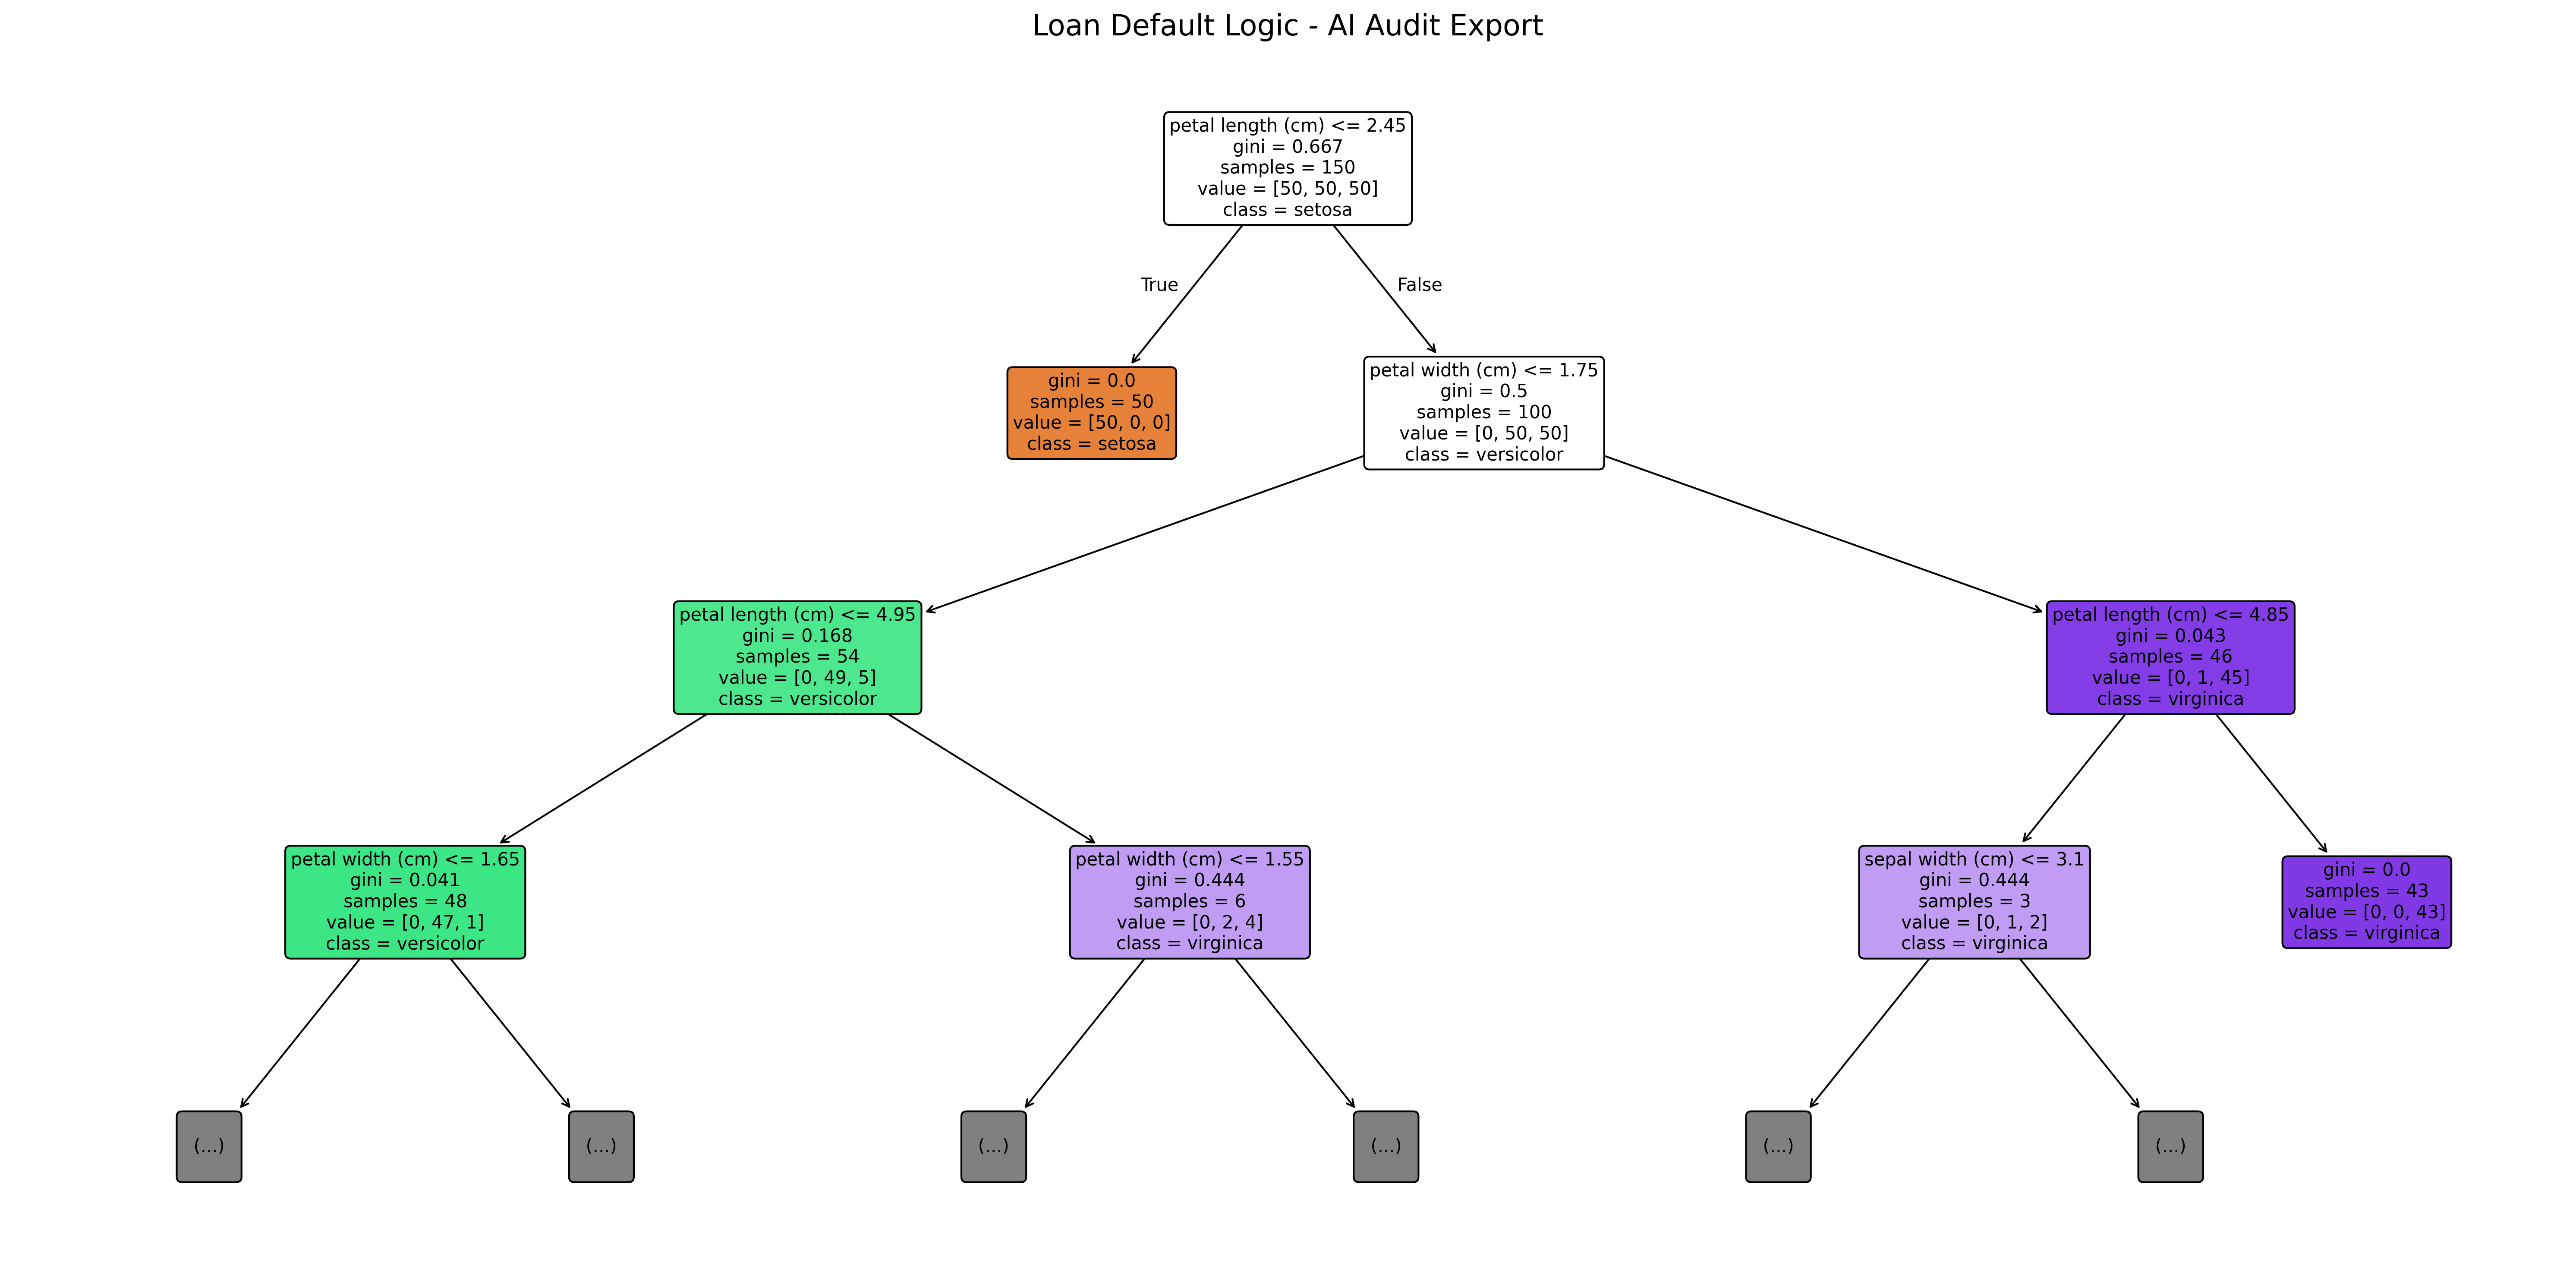

In [4]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 1. Loading Data and defining human-readable names
data = load_iris()
X, y = data.data, data.target
features = data.feature_names # e.g., ['sepal length (cm)', ...]
classes = data.target_names   # e.g., ['setosa', 'versicolor', 'virginica']

# 2. Training the Model (Engine)
clf = DecisionTreeClassifier(max_depth=4, random_state=42)
clf.fit(X, y)

# 3. Production Grade Visualization Setup
plt.figure(figsize=(20, 10), dpi=300) # High DPI for zooming in without pixelation

# 4. Executing plot_tree with full translation parameters
plot_tree(
    decision_tree=clf,
    max_depth=3,              # Visual depth limit (if tree is too deep)
    feature_names=features,   # Translation: X[0] -> 'sepal length'
    class_names=classes,      # Translation: 0 -> 'setosa'
    label='all',              # Show impurity, samples, and values
    filled=True,              # Color coding based on purity (Crucial for presentation)
    rounded=True,             # Aesthetic curves on boxes
    fontsize=10               # Readable text size
)

# 5. Save as a vector graphic for corporate presentations
plt.title("Loan Default Logic - AI Audit Export", fontsize=16)
plt.tight_layout()
# plt.savefig("tree_logic_audit.pdf", format="pdf") # Export as high-res PDF
# plt.show()

# NOTE on 2026 Modern Tooling: 
# While `plot_tree` is standard, modern industries often use the `dtreeviz` library
# which generates interactive HTML trees with distribution histograms inside each node!

### Master Class: Practical Engineering Guidelines for Decision Trees

#### 1. Basic Intuition (The Ground Reality)
Bhai, ek Decision Tree bilkul ek Formula 1 racing car ki tarah hota hai. Yeh bohot fast aur powerful hai, par agar track par kachra (noisy data), unbalanced turns (imbalanced classes), ya over-engineering (too many features) ho, toh yeh car crash ho jayegi (Overfitting/Failure). 

Industry me jab hum Decision Trees deploy karte hain, toh hum kabhi bhi raw data directly model me nahi daalte. Hum uske aage aur pichhe kuch "Safety Guards" lagate hain. Aaiye in practically proven safety guards ko ekdam deep engineering level par samajhte hain.

---

#### 2. Core Concepts & Architecture (Step-by-Step Breakdown)

**A. The Curse of Dimensionality & PCA**
* **The Problem:** Agar aapke paas 100 rows hain aur 500 columns (features) hain, toh tree ko overfit karne ka golden chance mil jata hai. Wo har ek column ko ek data point ke hisaab se tod kar 100% accuracy le aayega.
* **The Solution:** PCA (Principal Component Analysis) ya Feature Selection. Tree ko train karne se pehle hum PCA lagate hain jo 500 columns ko compress karke top 15-20 sabse important "Super-Columns" me badal deta hai. Isse tree sirf important patterns par dhyan deta hai, noise par nahi.

**B. The Imbalanced Class Trap**
* **The Problem:** Maan lijiye aap fraud detection bana rahe hain. 1 Lakh transactions me sirf 100 frauds hain (99.9% Safe, 0.1% Fraud). Agar tree sabko "Safe" bol de, toh bhi accuracy 99.9% aayegi! Tree fraud walon ko poori tarah ignore kar dega kyunki Gini impurity majority class ke favor me calculate hoti hai.
* **The Solution:** Data balancing. Iske do tarike hain:
  1. *Algorithm Level:* Sklearn me `class_weight='balanced'` use karein. Yeh minority class ki galti par bhari penalty lagata hai.
  2. *Data Level:* SMOTE (Synthetic Minority Over-sampling Technique) ka use karke fraud cases ke nakli (synthetic) data points banayein taaki ratio 50-50 ho jaye.

**C. Micro-Managing the Splits (`min_samples_split` & `min_samples_leaf`)**
* **`min_samples_split`:** Ek branch ko todne ke liye kam se kam kitne log chahiye? (Default 2 hai, jo bohot khatarnak hai. Industry me ise 10 ya 50 rakha jata hai).
* **`min_samples_leaf`:** Ek aakhiri patte (leaf) me kam se kam kitne log hone hi chahiye? Agar isko 1 chhod diya, toh tree ek akele outlier ke liye special rule bana lega (Overfitting). Agar isko bohot bada kar diya (e.g., 500), toh tree data padhega hi nahi (Underfitting). Ek sweet spot dhoondhna zaroori hai.

---

#### 3. Advanced Mathematics (Behind the Scenes)

**Mathematical Impact of `class_weight='balanced'`:**
Standard Gini Impurity calculation normal probabilities par kaam karti hai:
$p_i = \frac{N_i}{Total}$

Jab hum class weight lagate hain, toh Scikit-Learn background me probabilities aur errors ko inversely scale kar deta hai:
$$W_i = \frac{Total\_Samples}{n\_classes \times N_i}$$

Is formula ka magic dekhiye:
* Agar Fraud ($N_i$) bohot kam (100) hain, toh denominator chhota hoga, jisse Fraud ka Weight ($W_i$) bohot **bada (High Penalty)** aayega.
* Agar Safe transactions (99,900) hain, toh unka weight $1.0$ ke aas-paas aayega. 
Ab tree fraud pakadne ke liye jaan laga dega kyunki ek fraud miss karne par cost calculation me aag lag jayegi.

---

#### 4. Real-World Industry Use-Case
**Credit Card Fraud Detection Pipeline (Mastercard/Visa):**
Jab Mastercard ek real-time fraud detection tree banata hai, toh unka data highly imbalanced hota hai aur features bohot zyada hote hain (Time, IP Address, Device ID, Amount, Location, etc.). 
Wahan production pipeline me 3 cheezein hoti hain:
1. Pehle `PCA` lag kar 300 variables ko top 50 features me badla jata hai taaki latency milliseconds me rahe.
2. Training ke dauran SMOTE se data balance kiya jata hai.
3. `min_samples_leaf=100` set kiya jata hai, taaki agar koi ek naya ajeeb transaction aaye, toh system uske liye naya rule na banaye jab tak waise 100 transactions na dikhein. Yeh system ko highly stable banata hai.

---

#### 5. Modern Implementation (Production Grade Code)
Corporate code me in saari practical tips ko ek single, robust **Pipeline** me implement kiya jata hai. PCA aur Class Weights ka combination Tree ko fail hone se bachata hai.


In [5]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.datasets import make_classification

# Generating a Highly Imbalanced and High-Dimensional Dataset
# 100 features, but only 5% data is Class 1 (Fraud)
X, y = make_classification(n_samples=5000, n_features=100, n_informative=20, 
                           weights=[0.95], random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---- THE ULTIMATE PRODUCTION PIPELINE ----
# 1. StandardScaler: PCA ke liye data scale karna 100% zaroori hai.
# 2. PCA: 100 features ko reduce karke dimensionality kam karna.
# 3. DecisionTree: 'balanced' weight lagana taaki 5% fraud class ignore na ho.
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=15)), # Compress 100 columns into top 15 components
    ('tree', DecisionTreeClassifier(class_weight='balanced', random_state=42)) 
])

# ---- HYPERPARAMETER SAFETY NETS ----
param_grid = {
    # Tip 3: Start with max_depth=3 for visualization, but test higher for accuracy
    'tree__max_depth': [3, 5, 8, 12],
    
    # Tip 5: Micro-managing splits to avoid 1-sample overfitting
    'tree__min_samples_split': [10, 20, 50],
    'tree__min_samples_leaf': [5, 10, 20]
}

# Training the safe and robust model
grid_search = GridSearchCV(
    pipeline, 
    param_grid, 
    cv=5, 
    scoring='f1_macro', # Metric specifically for Imbalanced Data (Accuracy is fake here)
    n_jobs=-1
)

# grid_search.fit(X_train, y_train)
# print("Best Protected Tree Parameters:", grid_search.best_params_)